In [ ]:
# 이미지 10개 생성 테스트 코드

import os
import numpy as np
from tqdm import tqdm  # 진행바를 위한 모듈 (설치되어 있지 않다면 pip install tqdm)
from PIL import Image

# 1. 파일 및 저장 경로 설정
npz_path = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\QG_jets.npz"
output_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. npz 파일 로드 (키: X, y)
data = np.load(npz_path)
X = data['X']   # shape: (100000, M, 4)
y = data['y']   # shape: (100000,)

# 3. 전처리할 제트 수 설정 (여기서는 10개만)
num_images = 10
print(f"전체 {X.shape[0]}개 중 {num_images}개의 제트를 전처리합니다.")

# 전처리 파라미터
R = 0.4                # (η, φ) 범위: [-R, R]
img_size = 33          # 33×33 픽셀
pixel_extent = 2 * R   # 전체 범위: 0.8
pixel_size = pixel_extent / img_size  # 한 픽셀 당 길이

# num_images개의 제트 이미지를 저장할 배열 (각각 33×33)
jet_images = np.zeros((num_images, img_size, img_size), dtype=np.float32)

# 4. 각 제트에 대해 이미지 생성
# 각 제트의 shape는 (M, 4)이며, 피처는 [pt, rapidity, azimuth, pdgid] 입니다.
for i in tqdm(range(num_images), desc="Processing jets"):
    jet = X[i]
    pts = jet[:, 0]
    etas = jet[:, 1]
    phis = jet[:, 2]
    # pdgid = jet[:, 3]  # 필요 시 사용

    # 패딩된 입자(pt==0)는 무시
    valid = pts > 0
    if not np.any(valid):
        continue  # 모든 입자가 0이면 이미지 그대로 0

    pts_valid = pts[valid]
    etas_valid = etas[valid]
    phis_valid = phis[valid]

    # pT 가중 중심 계산
    sum_pt = np.sum(pts_valid)
    center_eta = np.sum(pts_valid * etas_valid) / sum_pt
    center_phi = np.sum(pts_valid * phis_valid) / sum_pt

    # 중심 정렬: 모든 입자의 (η, φ)에서 가중 중심 빼기
    etas_shifted = etas - center_eta
    phis_shifted = phis - center_phi

    # 제트 이미지 초기화
    image = np.zeros((img_size, img_size), dtype=np.float32)

    # 각 입자에 대해 해당 픽셀에 pt 값을 누적
    for pt, eta_val, phi_val in zip(pts, etas_shifted, phis_shifted):
        if pt <= 0:
            continue
        # cropping: (η, φ)가 [-R, R] 범위 내에 있는지 확인
        if (eta_val < -R) or (eta_val > R) or (phi_val < -R) or (phi_val > R):
            continue
        # (η, φ) = (-R, -R)이 (0,0) 픽셀이 되도록 픽셀 인덱스 계산
        ix = int((eta_val + R) / pixel_size)
        iy = int((phi_val + R) / pixel_size)
        ix = np.clip(ix, 0, img_size - 1)
        iy = np.clip(iy, 0, img_size - 1)
        image[ix, iy] += pt

    # 정규화: 전체 픽셀 합을 1로 (합이 0이면 그대로)
    total = image.sum()
    if total > 0:
        image /= total

    jet_images[i] = image

# 5. 전체 10개 제트에 대해 픽셀별 평균과 표준편차 계산 (zero-centering 및 표준화에 사용)
mean_image = np.mean(jet_images, axis=0)
std_image = np.std(jet_images, axis=0)
print("Mean and std image computed.")

# 6. 각 제트 이미지에 대해 후처리 (영점 조정, 표준화, 로그 스케일 변환, RGB 변환) 및 저장
for i in tqdm(range(num_images), desc="Saving images"):
    img = jet_images[i]

    # 영점 조정 및 표준화
    img_std = (img - mean_image) / (std_image + 1e-5)

    # [0, 1] 범위로 스케일링 (시각화를 위해 min–max 스케일링)
    img_std = img_std - img_std.min()
    if img_std.max() > 0:
        img_std = img_std / img_std.max()

    # 로그 스케일 적용: log1p(x) = log(1+x)
    img_log = np.log1p(img_std)
    if img_log.max() > 0:
        img_log = img_log / img_log.max()

    # 0~255 범위의 8비트 이미지로 변환
    img_uint8 = (img_log * 255).astype(np.uint8)

    # 단일 채널 이미지를 RGB 3채널 이미지로 복제
    img_rgb = np.stack([img_uint8, img_uint8, img_uint8], axis=-1)

    # 파일 이름 예시: jet_000001_label_0.png
    label = y[i]
    filename = os.path.join(output_dir, f"jet_{i:06d}_label_{int(label)}.png")
    Image.fromarray(img_rgb).save(filename)

print("10개의 이미지 저장 완료.")


전체 100000개 중 10개의 제트를 전처리합니다.


Processing jets: 100%|████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 313.84it/s]


Mean and std image computed.


Saving images: 100%|███████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 75.30it/s]

10개의 이미지 저장 완료.


In [ ]:
# 이미지 20000개 생성.
import os
import numpy as np
from tqdm import tqdm  # 진행바 표시 (설치: pip install tqdm)
from PIL import Image
import csv

# 1. 파일 및 저장 경로 설정
npz_path = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\QG_jets.npz"
output_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. npz 파일 로드 (키: X, y)
data = np.load(npz_path)
X = data['X']   # shape: (100000, M, 4), M: 입자 개수, (pt, eta, phi, pdgid)
y = data['y']   # shape: (100000,)

# 3. 전처리할 제트 수 (여기서는 20000개만)
num_images = 20000
print(f"전체 {X.shape[0]}개 중 앞의 {num_images}개 제트를 전처리합니다.")

# 전처리 파라미터
R = 0.4                # (η, φ) 범위: [-R, R]
img_size = 33          # 33×33 픽셀 이미지
pixel_extent = 2 * R   # 전체 범위: 0.8
pixel_size = pixel_extent / img_size  # 한 픽셀 당 길이

# 4. 결과 이미지를 저장할 배열 (shape: (num_images, 33, 33, 3))
jet_images = np.zeros((num_images, img_size, img_size, 3), dtype=np.float32)

# 하전 입자 판별 함수, 하전 입자면 true 반환?
def is_charged(pdgid):
    """
    pdgid 값을 기반으로 하전 입자 여부를 판단합니다.
    (여기서는 흔히 사용되는 하전 입자 PDG 코드: 211, 321, 2212와 그 음수값)
    """
    try:
        pdg = int(round(pdgid))
    except:
        pdg = 0
    charged_ids = {211, -211, 321, -321, 2212, -2212}
    return pdg in charged_ids

# 5. 각 제트에 대해 이미지 생성
for i in tqdm(range(num_images), desc="Processing jets"):
    jet = X[i]  # shape: (M, 4) → [pt, rapidity, azimuth, pdgid]
    pts    = jet[:, 0]
    etas   = jet[:, 1]
    phis   = jet[:, 2]
    pdgids = jet[:, 3]

    # pT > 0 인 유효 입자만 사용 (패딩된 입자 무시)
    valid = pts > 0
    if not np.any(valid):
        continue  # 모든 입자가 0이면 건너뛰기
    pts_valid   = pts[valid]
    etas_valid  = etas[valid]
    phis_valid  = phis[valid]
    pdgids_valid= pdgids[valid]

    # **중심 정렬 (Centering):** 모든 유효 입자에 대해 pT 가중 중심 계산?????
    sum_pt = np.sum(pts_valid)
    center_eta = np.sum(pts_valid * etas_valid) / sum_pt
    center_phi = np.sum(pts_valid * phis_valid) / sum_pt

    # 모든 입자의 (η, φ)를 중심 (0,0)으로 이동
    etas_shifted = etas - center_eta
    phis_shifted = phis - center_phi

    # 제트 이미지 (RGB, 33×33) 초기화
    image = np.zeros((img_size, img_size, 3), dtype=np.float32)

    # 각 입자에 대해 (η, φ) 좌표에 해당하는 픽셀에 값을 누적
    for pt, eta_val, phi_val, pdgid in zip(pts, etas_shifted, phis_shifted, pdgids):
        if pt <= 0:
            continue
        # cropping: (η, φ)가 [-R, R] 범위 내에 있어야 함
        if (eta_val < -R) or (eta_val > R) or (phi_val < -R) or (phi_val > R):
            continue
        # 픽셀 인덱스 계산 (η, φ = (-R,-R) → (0,0), (R,R) → (img_size-1, img_size-1))
        ix = int((eta_val + R) / pixel_size)
        iy = int((phi_val + R) / pixel_size)
        ix = np.clip(ix, 0, img_size - 1)
        iy = np.clip(iy, 0, img_size - 1)

        # 채널별 매핑:
        if is_charged(pdgid):
            # Red 채널: 하전 입자의 pT 누적
            image[ix, iy, 0] += pt
            # Blue 채널: 하전 입자 개수 (Multiplicity) 누적
            image[ix, iy, 2] += 1
        else:
            # Green 채널: 중성 입자의 pT 누적
            image[ix, iy, 1] += pt

    # **정규화 (Normalization):** 각 채널별로 전체 픽셀 합이 1이 되도록 함
    for ch in range(3):
        ch_sum = image[:, :, ch].sum()
        if ch_sum > 0:
            image[:, :, ch] /= ch_sum

    jet_images[i] = image

# 6. 전체 10개 제트에 대해 픽셀별, 채널별 평균과 표준편차 계산 (표준화에 사용)
mean_image = np.mean(jet_images, axis=0)  # shape: (33, 33, 3)
std_image  = np.std(jet_images, axis=0)   # shape: (33, 33, 3)
print("채널별 mean과 std 이미지 계산 완료.")

# 7. 각 제트 이미지에 대해 표준화 수행:
#    I_ij(k) -> (I_ij(k) - μ_ij(k)) / (σ_ij(k) + 1e-5)
jet_images_std = (jet_images - mean_image) / (std_image + 1e-5)

# 8. 학습/시각화용으로 PNG 파일로 저장하기 위해 [0,1] 범위로 min–max scaling 후, 0~255의 uint8로 변환
for i in range(num_images):
    img = jet_images_std[i]
    # 전체 이미지의 최소값을 0으로 shift
    img = img - img.min()
    # 최대값이 0보다 크면 [0,1]로 스케일링
    if img.max() > 0:
        img = img / img.max()
    # uint8 변환
    img_uint8 = (img * 255).astype(np.uint8)

    # 파일 이름 예: jet_000000.png, jet_000001.png, ...
    filename = os.path.join(output_dir, f"jet_{i:06d}.png")
    Image.fromarray(img_uint8).save(filename)

# 9. 제트에 대한 레이블 파일 생성 (CSV 파일: 파일명과 레이블: gluon=0, quark=1)
labels_list = []
for i in range(num_images):
    fname = f"jet_{i:06d}.png"
    label = int(y[i])
    labels_list.append((fname, label))

labels_csv_path = os.path.join(output_dir, "labels.csv")
with open(labels_csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["filename", "label"])
    writer.writerows(labels_list)

print("10개의 RGB 이미지와 레이블 CSV 파일(labels.csv)이 생성되었습니다.")


전체 100000개 중 앞의 20000개 제트를 전처리합니다.


Processing jets: 100%|██████████████████████████████████████████████████████████| 20000/20000 [00:47<00:00, 423.22it/s]


채널별 mean과 std 이미지 계산 완료.
10개의 RGB 이미지와 레이블 CSV 파일(labels.csv)이 생성되었습니다.


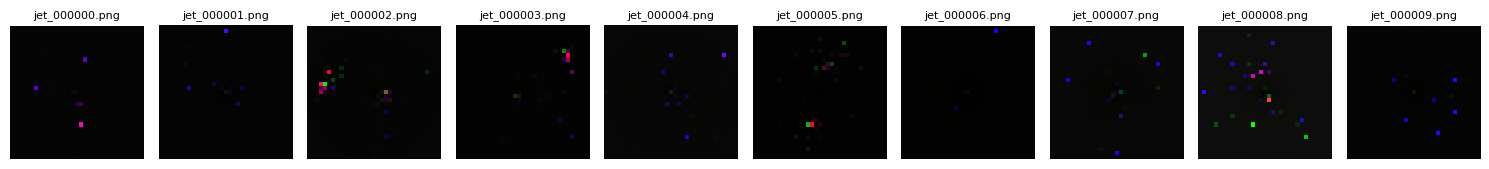

In [ ]:
# 10개만 이미지 출력해봄.

import os
import matplotlib.pyplot as plt
from PIL import Image

# 이미지 파일들이 저장된 디렉터리 경로
dataset_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset"

# 디렉터리 내의 PNG 파일들을 리스트로 가져오기 (정렬하여 순서를 맞춤)
image_files = sorted([f for f in os.listdir(dataset_dir) if f.endswith(".png")])

# 10개의 이미지 파일 선택 (npz 전처리 코드에서 저장한 순서와 동일하다고 가정)
num_images = 10
selected_images = image_files[:num_images]

# 10개의 이미지를 출력 (1행 10열 서브플롯)
plt.figure(figsize=(15, 3))
for i, image_file in enumerate(selected_images):
    img_path = os.path.join(dataset_dir, image_file)
    img = Image.open(img_path)
    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(image_file, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


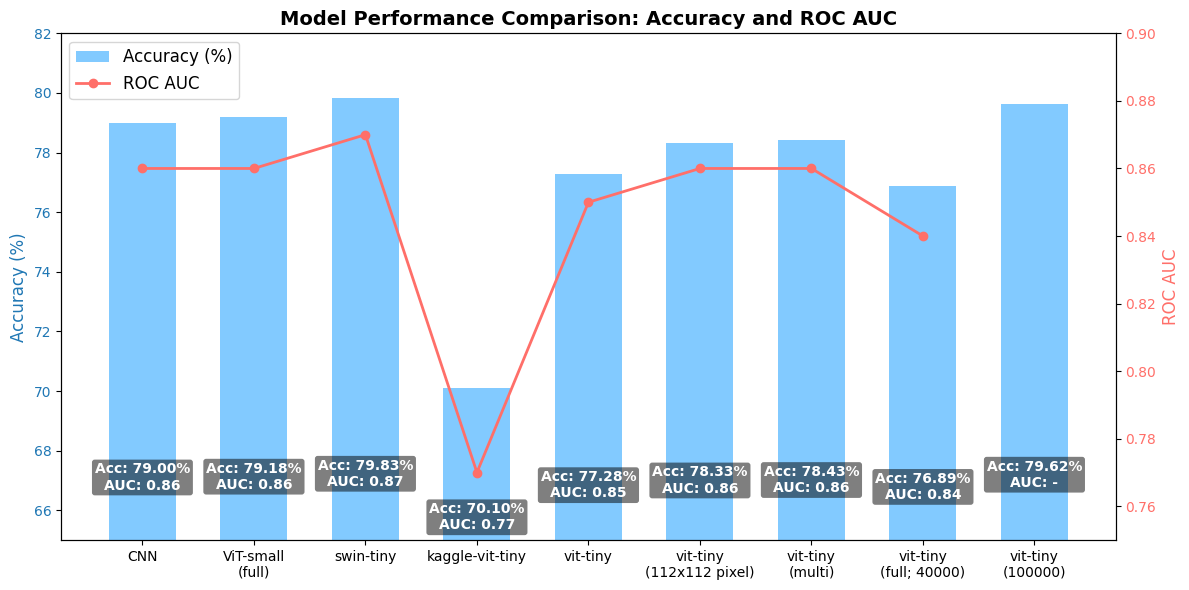

In [ ]:
# CNN
# 최대 정확도: 79%
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. CNN 모델 정의
# -----------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # 첫 번째 Conv Block: 3 -> 32 채널
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.25),  # Spatial Dropout, p=0.25
            nn.MaxPool2d(2)      # 33×33 → 약 16×16
        )
        # 두 번째 Conv Block: 32 -> 64 채널
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.5),   # Spatial Dropout, p=0.5
            nn.MaxPool2d(2)      # 16×16 → 약 8×8
        )
        # 세 번째 Conv Block: 64 -> 128 채널
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),   # Spatial Dropout, p=0.5
            nn.MaxPool2d(2)      # 8×8 → 약 4×4
        )
        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)  # 2 클래스: 예) gluon=0, quark=1
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x  # CrossEntropyLoss는 내부적으로 softmax를 적용하므로 raw logits를 출력

# -----------------------------
# 3. He-uniform (Kaiming uniform) weight 초기화 함수
# -----------------------------
def weight_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# -----------------------------
# 4. 메인 코드
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 및 미리보기
    df = pd.read_csv(labels_csv_path)
    print("CSV preview:")
    print(df.head())

    # train/validation 데이터셋 분할 (80:20, 클래스 비율 유지)
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels.csv")
    val_csv = os.path.join(dataset_dir, "val_labels.csv")
    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 5. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # 학습 시 데이터 증강(transformations)
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # 필요시 transforms.Normalize(mean, std) 추가
    ])

    # 검증 시 변환: Tensor 변환만 적용
    val_transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 6. 모델, 손실함수, 옵티마이저 설정
    # -----------------------------
    model = CNNClassifier().to(device)
    model.apply(weight_init)  # He-uniform 초기화 적용
    print(model)

    # Loss: Categorical Cross-Entropy (PyTorch의 CrossEntropyLoss는 logits를 입력받음)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # -----------------------------
    # 7. 학습 루프 (Early Stopping 없이 전체 에포크 진행)
    # -----------------------------
    num_epochs = 50

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # -----------------------------
    # 8. 최종 모델 저장
    # -----------------------------
    model_save_path = os.path.join(dataset_dir, "cnn_heatmap_classifier.pth")
    torch.save(model.state_dict(), model_save_path)
    print("Training complete. Final model saved at:", model_save_path)


Using device: cuda
CSV preview:
         filename  label
0  jet_000000.png      1
1  jet_000001.png      1
2  jet_000002.png      1
3  jet_000003.png      1
4  jet_000004.png      1
CNNClassifier(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.5, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, mom

Epoch 1/50 - Validation: 100%|█████████████████████████████████████████████████████████| 32/32 [00:03<00:00,  9.54it/s]


Epoch 1/50: Train Loss: 0.7707, Train Acc: 0.5712 | Val Loss: 0.6249, Val Acc: 0.6683


Epoch 2/50 - Validation: 100%|█████████████████████████████████████████████████████████| 32/32 [00:03<00:00,  9.92it/s]


Epoch 2/50: Train Loss: 0.6340, Train Acc: 0.6491 | Val Loss: 0.5959, Val Acc: 0.6935


...

Epoch 48/50: Train Loss: 0.4964, Train Acc: 0.7750 | Val Loss: 0.4628, Val Acc: 0.7895


Epoch 49/50 - Validation: 100%|████████████████████████████████████████████████████████| 32/32 [00:03<00:00, 10.36it/s]


Epoch 49/50: Train Loss: 0.4949, Train Acc: 0.7739 | Val Loss: 0.4630, Val Acc: 0.7875


Epoch 50/50 - Validation: 100%|████████████████████████████████████████████████████████| 32/32 [00:03<00:00,  9.66it/s]

Epoch 50/50: Train Loss: 0.4913, Train Acc: 0.7778 | Val Loss: 0.4628, Val Acc: 0.7905
Training complete. Final model saved at: C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset\cnn_heatmap_classifier.pth


In [ ]:
# ViT -tiny
# 77.28%
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 ViT 모델 파인튜닝 - 후반 4개 블록만 학습)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 및 train/validation 분할 (클래스 비율 유지)
    df = pd.read_csv(labels_csv_path)
    print("CSV preview:")
    print(df.head())
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels.csv")
    val_csv = os.path.join(dataset_dir, "val_labels.csv")
    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # vit_tiny_patch16_224 모델의 기본 입력 크기인 224×224에 맞춰 전처리합니다.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        # transforms.RandomHorizontalFlip(),  # 데이터 증강 옵션 (필요 시 사용)
        # transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # 필요시 transforms.Normalize(mean, std) 추가
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정 (후반 4개 블록만 학습)
    # -----------------------------
    # 'vit_tiny_patch16_224' 모델을 사전 학습된 가중치로 불러오고,
    # 분류 헤드를 우리의 클래스 수(여기서는 2)로 맞춥니다.
    model_name = 'vit_tiny_patch16_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)

    # 전체 Transformer 블록 중, 마지막 4개 블록만 학습시키고 나머지는 동결합니다.
    total_blocks = len(model.blocks)
    num_trainable = 4  # 마지막 4개의 블록만 학습
    for i, block in enumerate(model.blocks):
        # 초반 블록부터 total_blocks - num_trainable 까지 동결(freeze)
        if i < total_blocks - num_trainable:
            for param in block.parameters():
                param.requires_grad = False

    model = model.to(device)
    print(model)

    # -----------------------------
    # 5. 학습에 필요한 손실함수와 옵티마이저 설정
    # -----------------------------
    criterion = nn.CrossEntropyLoss()
    # 동결되지 않은 파라미터들만 업데이트합니다.
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    # -----------------------------
    # 6. 학습 루프
    # -----------------------------
    num_epochs = 50
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # -----------------------------
    # 7. 최종 모델 저장
    # -----------------------------
    model_save_path = os.path.join(dataset_dir, "timm_vit_finetuned.pth")
    torch.save(model.state_dict(), model_save_path)
    print("Training complete. Final model saved at:", model_save_path)


Using device: cuda
CSV preview:
         filename  label
0  jet_000000.png      1
1  jet_000001.png      1
2  jet_000002.png      1
3  jet_000003.png      1
4  jet_000004.png      1
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(


Epoch 1/50 - Validation: 100%|█████████████████████████████████████████████████████████| 32/32 [00:20<00:00,  1.57it/s]


Epoch 1/50: Train Loss: 0.6403, Train Acc: 0.6837 | Val Loss: 0.5189, Val Acc: 0.7445


Epoch 2/50 - Validation: 100%|█████████████████████████████████████████████████████████| 32/32 [00:10<00:00,  3.15it/s]


Epoch 2/50: Train Loss: 0.4997, Train Acc: 0.7606 | Val Loss: 0.5266, Val Acc: 0.7265


...

Epoch 17/50: Train Loss: 0.4161, Train Acc: 0.8135 | Val Loss: 0.5282, Val Acc: 0.7608


Epoch 18/50 - Validation: 100%|████████████████████████████████████████████████████████| 32/32 [00:10<00:00,  3.15it/s]


Epoch 18/50: Train Loss: 0.4103, Train Acc: 0.8167 | Val Loss: 0.5042, Val Acc: 0.7642


Epoch 19/50 - Validation:  94%|████████████████████████████████████████████████████▌   | 30/32 [00:09<00:00,  3.10it/s]


KeyboardInterrupt: 

In [ ]:
# vit_small (full)
# 최대 정확도 : 79.18%
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 ViT 모델 파인튜닝 - 전체 fine-tuning)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 및 train/validation 분할 (클래스 비율 유지)
    df = pd.read_csv(labels_csv_path)
    print("CSV preview:")
    print(df.head())
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels.csv")
    val_csv = os.path.join(dataset_dir, "val_labels.csv")
    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # ImageNet 기준 평균, 표준편차 (ViT 모델의 사전학습에 사용된 값)
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    # 학습 시: RandomResizedCrop, 다양한 augmentation, 정규화 적용
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    # 검증 시: Resize 후 CenterCrop, 정규화 적용
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 128
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정
    # -----------------------------
    # 보다 무거운 모델을 사용 (예: vit_small_patch16_224)
    model_name = 'vit_small_patch16_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)
    # 전체 파라미터를 fine-tuning 하도록 동결(freeze) 코드는 사용하지 않음

    model = model.to(device)
    print(model)

    # 학습에 필요한 손실함수와 옵티마이저 설정
    criterion = nn.CrossEntropyLoss()
    # AdamW를 사용하고, weight_decay를 추가하여 정규화 효과도 줌
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    # 학습률 스케줄러 (CosineAnnealingLR: epoch이 진행됨에 따라 lr을 점차 낮춤)
    num_epochs = 25
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # -----------------------------
    # 5. 학습 루프
    # -----------------------------
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # 스케줄러 업데이트
        scheduler.step()

    # -----------------------------
    # 6. 최종 모델 저장
    # -----------------------------
    model_save_path = os.path.join(dataset_dir, "timm_vit_finetuned_heavy.pth")
    torch.save(model.state_dict(), model_save_path)
    print("Training complete. Final model saved at:", model_save_path)


Using device: cuda
CSV preview:
         filename  label
0  jet_000000.png      1
1  jet_000001.png      1
2  jet_000002.png      1
3  jet_000003.png      1
4  jet_000004.png      1
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(

Epoch 1/25 - Validation: 100%|█████████████████████████████████████████████████████████| 32/32 [00:17<00:00,  1.79it/s]


Epoch 1/25: Train Loss: 0.5789, Train Acc: 0.7075 | Val Loss: 0.5303, Val Acc: 0.7343


Epoch 2/25 - Validation: 100%|█████████████████████████████████████████████████████████| 32/32 [00:17<00:00,  1.81it/s]


Epoch 2/25: Train Loss: 0.5308, Train Acc: 0.7378 | Val Loss: 0.5147, Val Acc: 0.7410


...

Epoch 23/25: Train Loss: 0.4405, Train Acc: 0.7941 | Val Loss: 0.4625, Val Acc: 0.7833


Epoch 24/25 - Validation: 100%|████████████████████████████████████████████████████████| 32/32 [00:18<00:00,  1.73it/s]


Epoch 24/25: Train Loss: 0.4369, Train Acc: 0.7979 | Val Loss: 0.4612, Val Acc: 0.7873


Epoch 25/25 - Validation: 100%|████████████████████████████████████████████████████████| 32/32 [00:18<00:00,  1.73it/s]


Epoch 25/25: Train Loss: 0.4314, Train Acc: 0.8024 | Val Loss: 0.4611, Val Acc: 0.7835
Training complete. Final model saved at: C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset\timm_vit_finetuned_heavy.pth
